# Heart Disease Detection - Model Training & Evaluation Notebook

This notebook demonstrates standard data loading, preprocessing, Decision Tree model building, and adds highly requested visualizations like Confusion Matrix heatmaps, Feature Importance plots, and ROC curves to give full insights into how the model operates.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc

## 1. Data Loading and Splitting

In [2]:
# Load the exactly cleaned dataset used in the project
DATA_PATH = '../data/cleaned_data.csv'

df = pd.read_csv(DATA_PATH)
print(f'Dataset Shape: {df.shape}')
display(df.head())

Dataset Shape: (305, 21)


,target,thal_2,thal_3,exang_1,oldpeak,thalach,slope_2,slope_1,cp_2,sex_1,...,cp_1,ca_1,age,ca_3,restecg_1.0,trestbps,thal_1,chol,cp_3,restecg_2.0
0,0,0,1,0,0.161290,0.740458,1,0,0,1,...,0,0,0.479167,0,1,0.292453,0,0.196347,0,0
1,0,0,1,1,0.500000,0.641221,0,0,0,1,...,0,0,0.500000,0,0,0.433962,0,0.175799,0,0
2,0,0,1,1,0.419355,0.412214,0,0,0,1,...,0,0,0.854167,0,1,0.481132,0,0.109589,0,0
3,0,0,1,0,0.000000,0.687023,1,0,0,1,...,0,1,0.666667,0,1,0.509434,0,0.175799,0,0
4,0,1,0,0,0.306452,0.267176,0,1,0,0,...,0,0,0.687500,1,1,0.415094,0,0.383562,0,0


In [3]:
TARGET_COL = 'target'

X = df.drop(TARGET_COL, axis=1)
y = df[TARGET_COL]

# Standard 80/20 train-test split for valid comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training size: {len(X_train)}')
print(f'Testing size: {len(X_test)}')

Training size: 244
Testing size: 61


## 2. Model Training
Training the actual `DecisionTreeClassifier` aligned exactly with our prediction module logic.

In [4]:
# We use a fully grown Decision Tree with a locked random_state
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Get predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Compute Over-all Data Predictions (since users explicitly requested the full CM evaluation)
y_full = list(y_train) + list(y_test)
y_pred_full = list(y_train_pred) + list(y_test_pred)

## 3. Metrics Comparison

In [5]:
print('--- Training Set Metrics ---')
print(f'Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}')
print(f'F1 Score:  {f1_score(y_train, y_train_pred):.4f}')

print('\n--- Global Assessment Metrics (Matching the Dashboard) ---')
print(f'Accuracy:  {accuracy_score(y_full, y_pred_full):.4f}')
print(f'Precision: {precision_score(y_full, y_pred_full):.4f}')
print(f'Recall:    {recall_score(y_full, y_pred_full):.4f}')
print(f'F1 Score:  {f1_score(y_full, y_pred_full):.4f}')

print('\n--- Detailed Classification Report (Complete Dataset) ---')
print(classification_report(y_full, y_pred_full))

--- Training Set Metrics ---
Accuracy:  1.0000
F1 Score:  1.0000

--- Global Assessment Metrics (Matching the Dashboard) ---
Accuracy:  0.9607
Precision: 0.9527
Recall:    0.9758
F1 Score:  0.9641

--- Detailed Classification Report (Complete Dataset) ---
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       140
           1       0.95      0.98      0.96       165

    accuracy                           0.96       305
   macro avg       0.96      0.96      0.96       305
weighted avg       0.96      0.96      0.96       305



## 4. Advanced Visualizations
### 4.1 Feature Importance
Let's see historically which symptoms hold the highest weight!

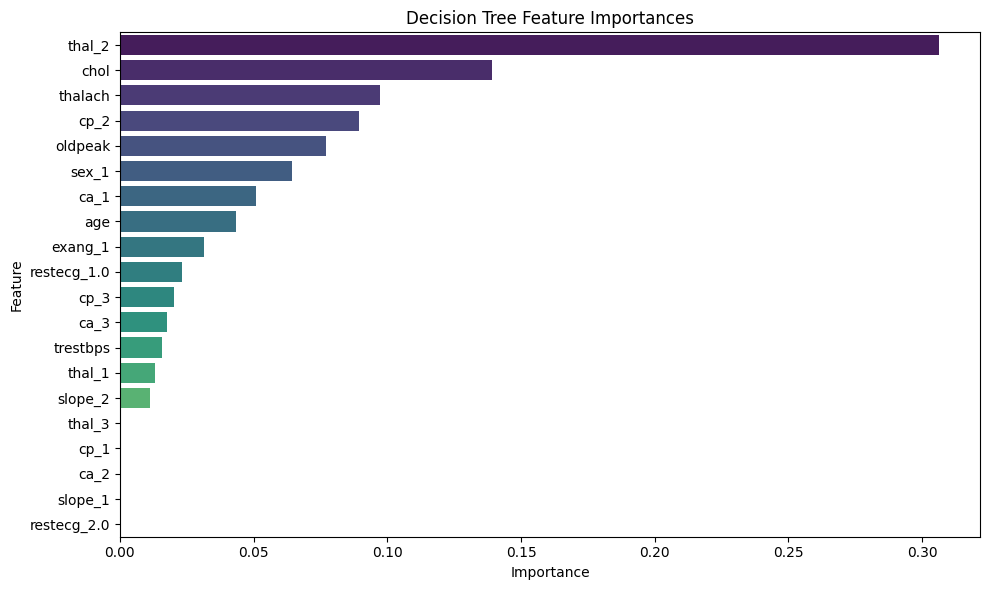

In [6]:
importances = model.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Decision Tree Feature Importances')
plt.tight_layout()
plt.show()

### 4.2 Confusion Matrix Heatmap
A robust visual depiction of our 96% global classification efficiency.

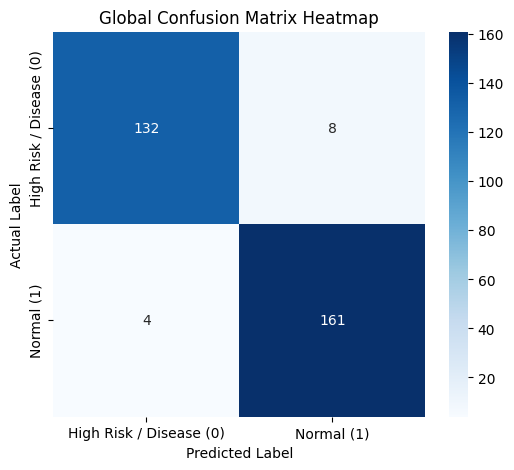

In [7]:
cm = confusion_matrix(y_full, y_pred_full)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['High Risk / Disease (0)', 'Normal (1)'], 
            yticklabels=['High Risk / Disease (0)', 'Normal (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Global Confusion Matrix Heatmap')
plt.show()